# DX 602 Final Project

## Introduction

In this project, you will practice the skills that you have learned throughout this module with a heavy focus on building models.
Most of the problems and questions are open ended compared to your previous homeworks, and you will be asked to explain your choices.
Most of them will have a particular type of solution implied, but it is up to you to figure out the details based on what you have learned in this module.

## Instructions

Each problem asks you to perform build models, run a computation, or otherwise perform some analysis of the data, and usually answer some questions about the results.
Make sure that your question answers are well supported by your analysis and explanations; simply stating an answer without support will earn minimal points.

Notebook cells for code and text have been added for your convenience, but feel free to add additional cells.

## Example Code

You may find it helpful to refer to this GitHub repository of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Submission

This project will be entirely manually graded.
However, we may rerun some or all of your code to confirm that it works as described.

### Late Policy

The normal homework late policy for OMDS does not apply to this project.
Boston University requires final grades to be submitted within 72 hours of class instruction ending, so we cannot accommodate 5 days of late submissions.

However, we have delayed the due date of this project to be substantially later than necessary given its scope, and given you more days for submission with full credit than you would have had days for submission with partial credit under the homework late policy.
The Thanksgiving holiday was also taken into account in setting the deadline.
Finally, the deadlines for DX 601 and DX 602 were coordinated to be a week apart while giving ample time for both of their projects.

## Shared Imports

For this project, you are forbidden to use modules that were not loaded in this template.
While other modules are handy in practice, modules that trivialize these problems interfere with our assessment of your own knowledge and skills.

If you believe a module covered in the course material (not live sessions) is missing, please check with your learning facilitator.

In [31]:
import math
import sys

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import sklearn.linear_model

## Problems

### Problem 1 (5 points)

Pick one of the following data sets to analyze in this project.
Load the data set, and show a random sample of 10 rows.

* [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) ([PMLB - red subset only](https://github.com/EpistasisLab/pmlb/tree/master/datasets/wine_quality_red))
* [Body Fat](https://www.openml.org/search?type=data&status=active&id=560) ([PMLB](https://github.com/EpistasisLab/pmlb/tree/master/datasets/560_bodyfat))

The PMLB copies of the data are generally cleaner and recommended for this project, but the other links are provided to give you more context.
To load the data from the PMLB Github repository, navigate to the `.tsv.gz` file in GitHub and copy the link from the "Raw" button.

If the dataset has missing data, you should drop the rows with missing data before proceeding.
If the data set you choose has more than ten columns, you may limit later analysis that is requested per column to just the first ten columns.

In [33]:
# Load the Dataset

body_fat = pd.read_csv("https://github.com/EpistasisLab/pmlb/raw/refs/heads/master/datasets/560_bodyfat/560_bodyfat.tsv.gz",sep="\t")

In [34]:
# Check the shape of the Dataset

body_fat.shape

(252, 15)

In [35]:
# Show a random sample of 10 rows in the Dataset

body_fat.sample(10)

,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,target
177,1.0316,37.0,241.25,71.50,42.099998,119.199997,110.300003,113.900002,69.800003,42.599998,24.799999,34.400002,29.500000,18.400000,29.900000
49,1.0903,47.0,127.50,66.75,34.000000,83.400002,70.400002,87.199997,50.599998,34.400002,21.900000,26.799999,25.799999,16.799999,4.000000
220,1.0706,54.0,153.25,70.50,38.500000,99.000000,91.800003,96.199997,57.700001,38.099998,23.900000,31.400000,29.900000,18.900000,12.400000
241,1.0207,65.0,224.50,68.25,38.799999,119.599998,118.000000,114.300003,61.299999,42.099998,23.400000,34.900002,30.100000,19.400000,35.000000
204,1.0209,44.0,223.00,69.75,40.900002,121.599998,113.900002,107.099998,63.500000,40.299999,21.799999,34.799999,30.700001,17.400000,34.799999
173,1.0603,36.0,176.25,71.50,38.700001,98.199997,90.300003,99.900002,59.200001,37.700001,21.500000,32.400002,28.400000,17.799999,16.900000
245,1.0641,68.0,155.50,69.25,36.299999,97.400002,84.300003,94.400002,54.299999,37.500000,22.600000,29.200001,27.299999,18.500000,15.200000
82,1.0568,64.0,190.25,72.75,39.299999,103.099998,97.800003,99.599998,58.900002,39.000000,23.000000,34.299999,29.600000,19.000000,18.400000
73,1.0680,55.0,125.00,64.00,33.200001,87.699997,76.000000,88.599998,50.900002,35.400002,19.100000,29.299999,25.700001,16.900000,13.500000
181,1.1089,40.0,118.50,68.00,33.799999,79.300003,69.400002,85.000000,47.200001,33.500000,20.200001,27.700001,24.600000,16.500000,0.000000


In [36]:
# Drop rows with missing data

body_fat = body_fat.dropna()

In [37]:
# Check the shape of the dataframe again

body_fat.shape

(252, 15)

In [38]:
# Set the dataframe to just 10 columns

body_fat = body_fat[["Density", "Age", "Weight", "Height", "Neck", "Chest", "Abdomen", "Hip", "Thigh", "target"]]

In [39]:
# Check the shape of the dataframe again to endure 10 columns

body_fat.shape

(252, 10)

In [40]:
# Show a random sample of 10 rows, with just the 10 columns

body_fat.sample(10)

,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,target
14,1.0484,35.0,187.75,69.50,40.500000,101.300003,96.400002,100.099998,69.000000,22.100000
145,1.0664,24.0,156.00,70.75,35.700001,92.699997,81.900002,95.300003,56.400002,14.200000
224,1.0740,55.0,179.75,68.75,41.099998,106.900002,95.300003,98.199997,57.400002,10.900000
6,1.0549,26.0,181.00,69.75,36.400002,105.099998,90.699997,100.300003,58.400002,19.200001
154,1.0510,27.0,200.25,73.50,38.200001,101.099998,100.099998,105.000000,62.099998,21.000000
75,1.0666,61.0,148.25,67.50,36.000000,91.599998,81.800003,94.800003,54.500000,18.500000
136,1.0491,39.0,166.75,70.75,37.000000,92.900002,86.099998,95.599998,58.799999,21.799999
142,1.0459,52.0,167.00,67.75,37.500000,102.699997,91.000000,98.900002,57.099998,23.299999
94,1.0785,47.0,184.25,74.50,37.299999,99.599998,88.800003,101.400002,57.400002,9.000000
0,1.0708,23.0,154.25,67.75,36.200001,93.099998,85.199997,94.500000,59.000000,12.300000


YOUR ANSWERS HERE

### Problem 2 (10 points)

List all of the columns and describe them in your own words.

In [41]:
# YOUR CODE HERE: List all of the columns
body_fat.columns

Index(['Density', 'Age', 'Weight', 'Height', 'Neck', 'Chest', 'Abdomen', 'Hip',
       'Thigh', 'target'],
      dtype='object')

### Describe the Columns:
* Density: Body Density of the men being studied, measured in (gm/cm^3)
* Age: the age of the men being studied, measured in (years)
* Weight: the weight of the men being studied, measured in (lbs)
* Height: height of the men being studied, measured in (inches)
* Neck: circumference measurement of the neck of the men being studied, measured in (cm)
* Chest: circumference measurement of the chest of the men being studied, measured in (cm)
* Abdomen: circumference measurement of the abdomen of the men being studied, measured in (cm)
* Hip: circumference measurement of the hip of the men being studied, measured in (cm)
* Thigh: circumference measurement of the thigh of the men being studied, measured in (cm)
* target: the percentage of body fat determined by underwater weighing

YOUR ANSWERS HERE

### Problem 3 (50 points)

Perform an exploratory analysis of the data set.
After your exploratory analysis, pick 3 individual charts that you the think were particularly interesting.
Repeat those charts separately from your original analysis, and after each of those charts, explain what you thought was noteworthy.

In [42]:
# Check for missing data and the data type of each column
body_fat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   Age      252 non-null    float64
 2   Weight   252 non-null    float64
 3   Height   252 non-null    float64
 4   Neck     252 non-null    float64
 5   Chest    252 non-null    float64
 6   Abdomen  252 non-null    float64
 7   Hip      252 non-null    float64
 8   Thigh    252 non-null    float64
 9   target   252 non-null    float64
dtypes: float64(10)
memory usage: 19.8 KB


In [43]:
# To see the statistics on all the numeric columns

body_fat.describe()

,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,target
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,1.055574,44.884921,178.924405,70.148810,37.992064,100.824206,92.555952,99.904762,59.405952,19.150794
std,0.019031,12.602040,29.389160,3.662856,2.430913,8.430476,10.783077,7.164058,5.249952,8.368740
min,0.995000,22.000000,118.500000,29.500000,31.100000,79.300003,69.400002,85.000000,47.200001,0.000000
25%,1.041400,35.750000,159.000000,68.250000,36.400002,94.350000,84.574999,95.500000,56.000000,12.475000
50%,1.054900,43.000000,176.500000,70.000000,38.000000,99.649998,90.950001,99.300003,59.000000,19.200001
75%,1.070400,54.000000,197.000000,72.250000,39.425001,105.375002,99.324997,103.525000,62.349999,25.299999
max,1.108900,81.000000,363.149994,77.750000,51.200001,136.199997,148.100006,147.699997,87.300003,47.500000


In [44]:
# To see the number of rows and number of columns 

body_fat.shape

(252, 10)

In [45]:
# To look at the number of unique values in each Column
# -- Typically a better measure for string / classification

body_fat.nunique()

Density    218
Age         51
Weight     197
Height      48
Neck        90
Chest      174
Abdomen    185
Hip        152
Thigh      139
target     176
dtype: int64

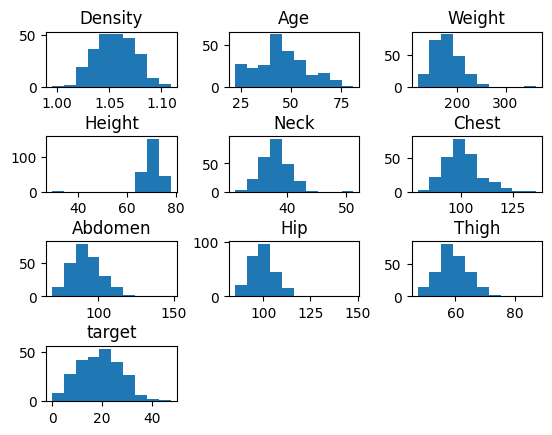

In [46]:
# To see the Distributions of all the columns via Histograms

body_fat.hist(grid=False)
plt.subplots_adjust(wspace=0.4, hspace=0.9)

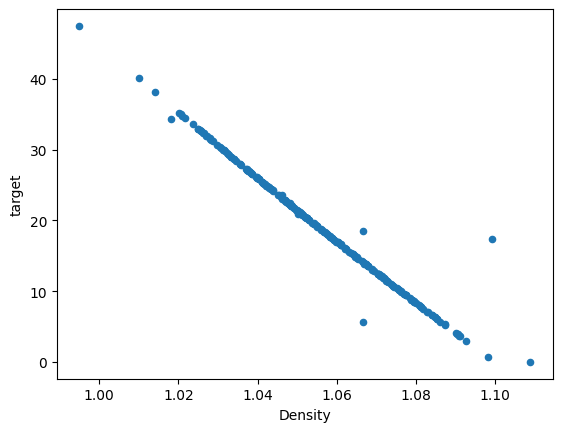

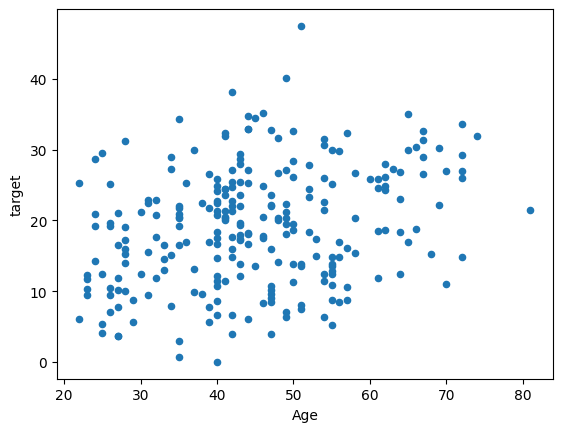

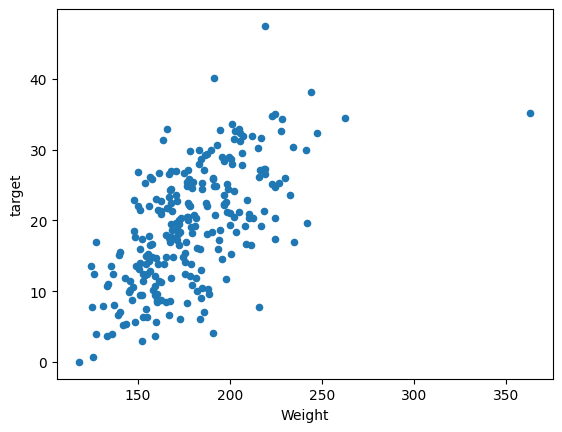

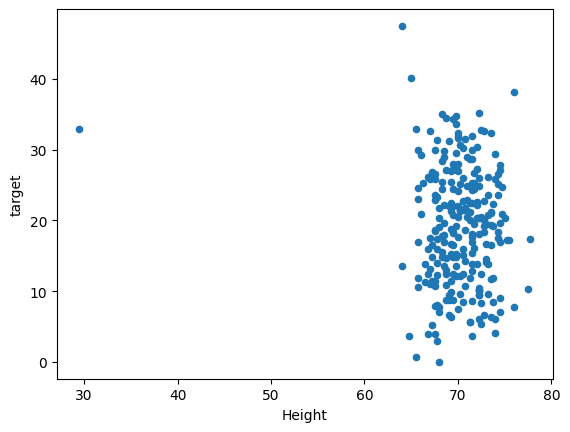

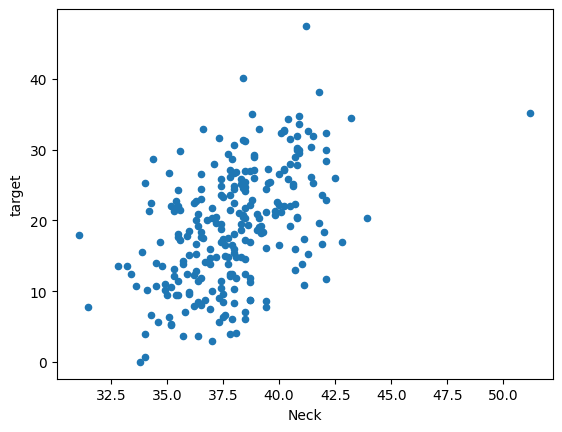

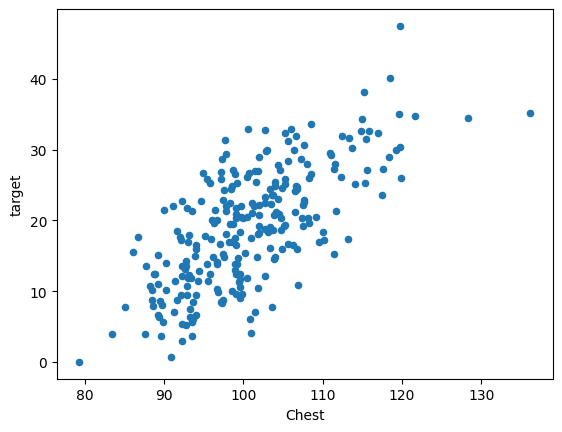

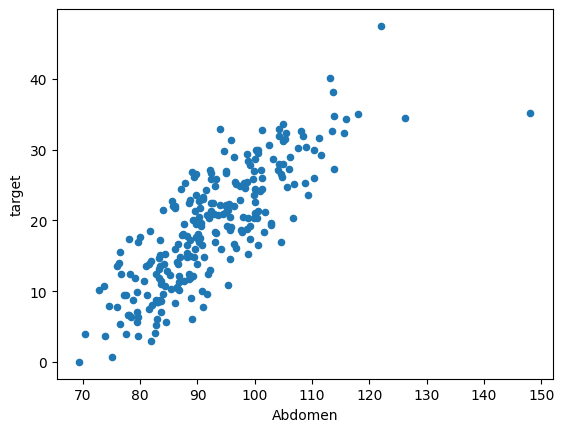

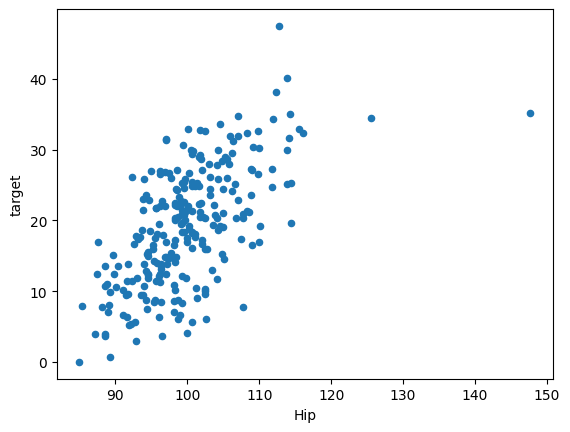

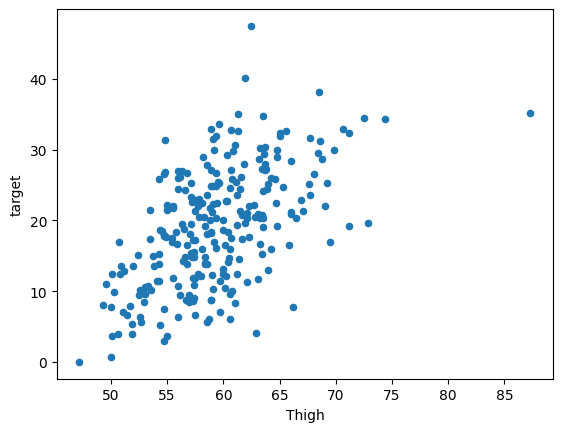

In [47]:
# Look at every columns vs. the target column to see correlation

for c in body_fat.columns:
    if c == "target":
        continue
    body_fat.plot.scatter(x=c, y="target")
    plt.xlabel(c)
    plt.ylabel("target")
    plt.show()


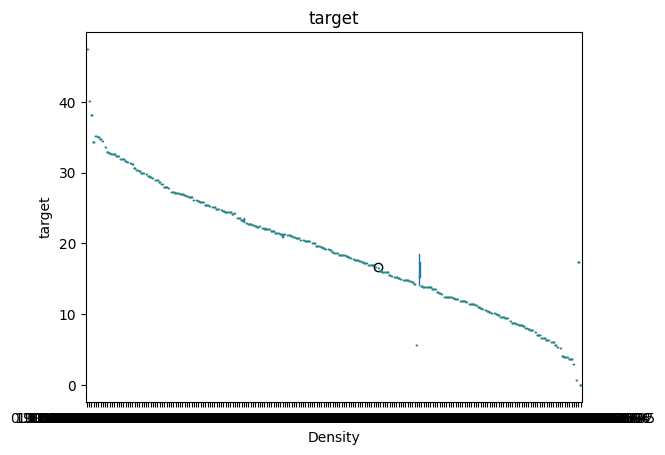

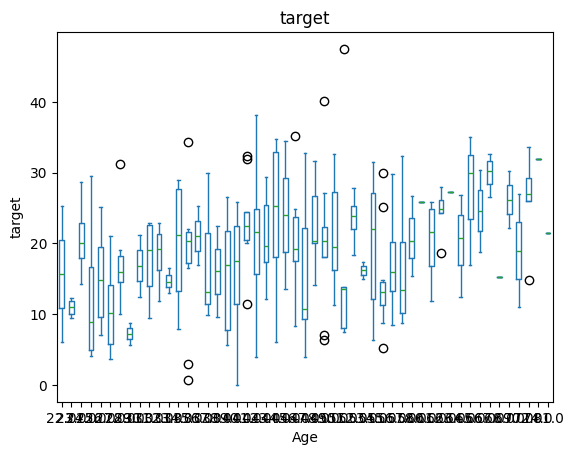

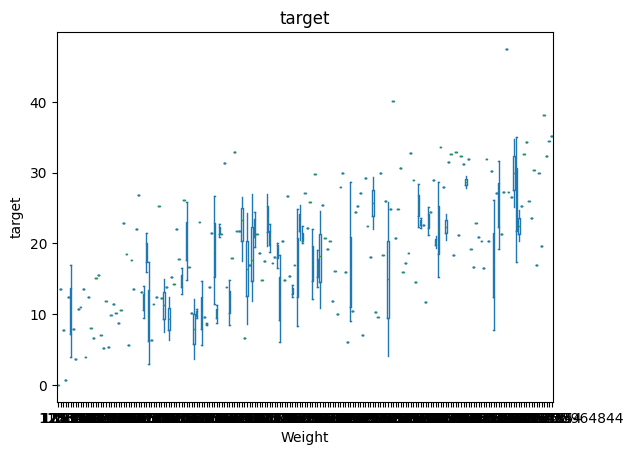

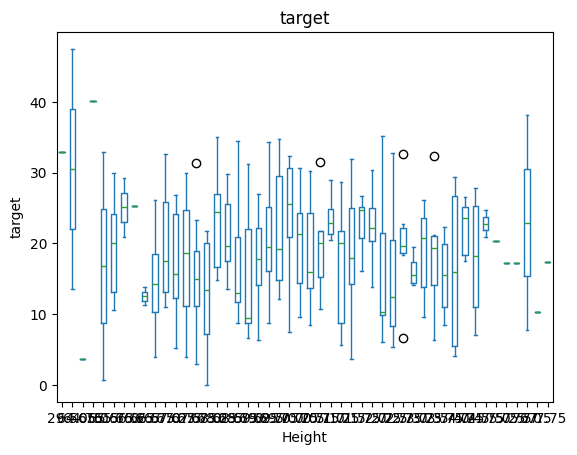

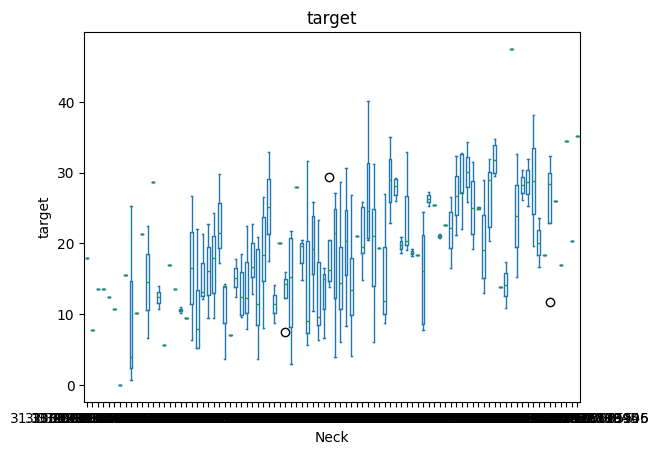

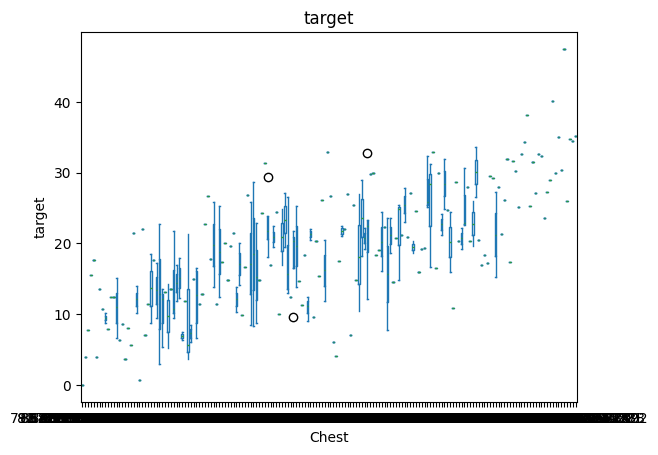

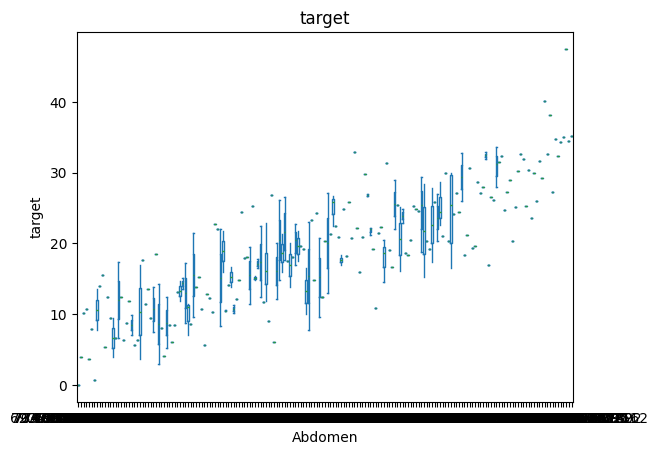

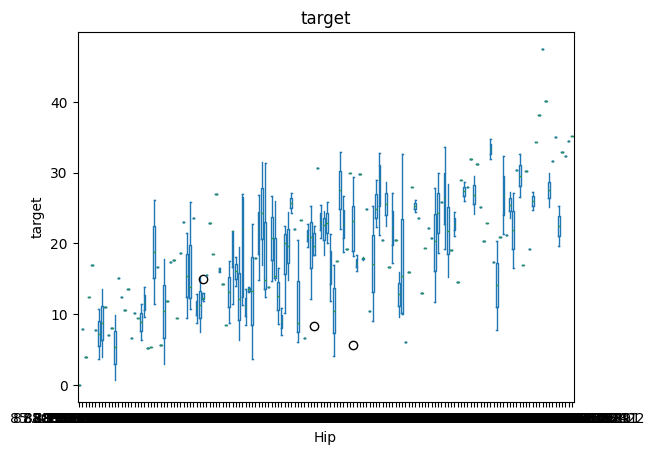

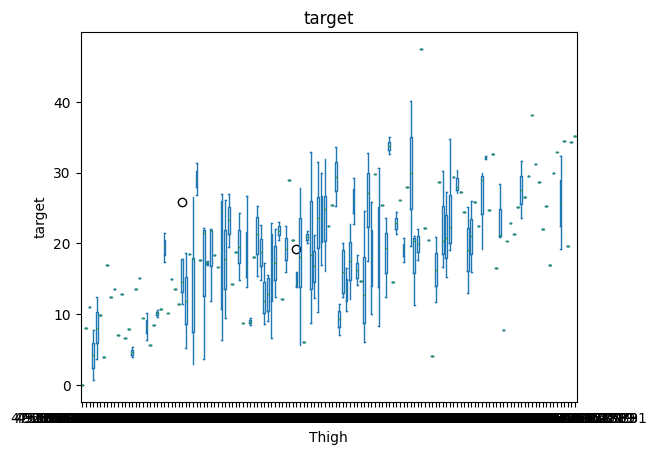

In [48]:
# Look at Box Plots of every Column to Check for Outlier

for c in body_fat.columns:
    if c == "target":
        continue
    body_fat.plot.box(column="target", by=c)
    plt.xlabel(c)
    plt.ylabel("target")
    plt.show()

### 3 Charts that were Particularly Interesting

Text(0.5, 1.0, 'Scatter Plot of Density vs. Percentage of Body Fat')

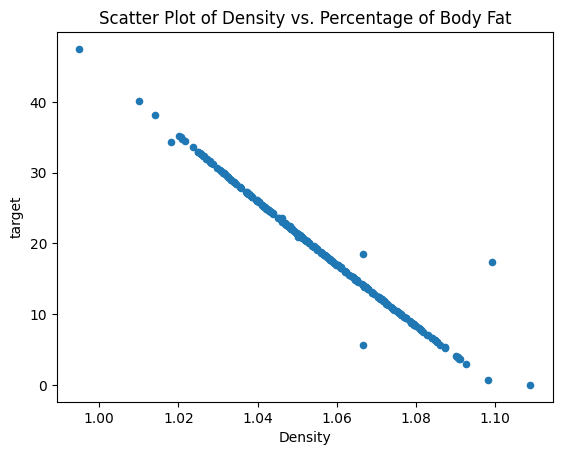

In [49]:
# Chart 1 - Scatter Plot of Density vs. Percentage of Body Fat

body_fat.plot.scatter(x="Density", y="target")
plt.title("Scatter Plot of Density vs. Percentage of Body Fat")

I found the chart that shows the relationship between body fat and density to be very interesting because of the strong correlation between the two values. Via plotting density v. body fat, you can see the strong inverse relationship that exists between the two. It is clear the two have a strong linear inverse relationship. From a conceptual perspective, this makes sense as density increases, one would expect fat to decrease. A higher fat concentration would cause particles to be more spaced out, which would result in a lower density.

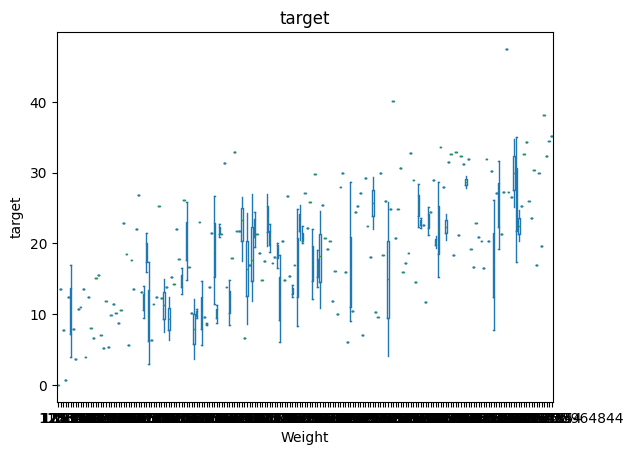

In [50]:
# Chart 2 - Box Plot of Weight vs. Percentage of Body Fat

body_fat.plot.box(column="target", by="Weight")
plt.xlabel("Weight")
plt.ylabel("target")
plt.show()

The second chart I found interesting was the box plot of the target column by the weight column. The reason I found this chart intersting was because of the presence of outliers in the weight column. When looking at the describe function, it can be seen that the weight column has a high standard deviation of 29.39, so it makes sense that the data would appear spread out. Additionally, the 75th percentile of the column is 197 where as the max is 363. Therefore, we know outliers must exist in this column, but this box plot visualization confirms it.

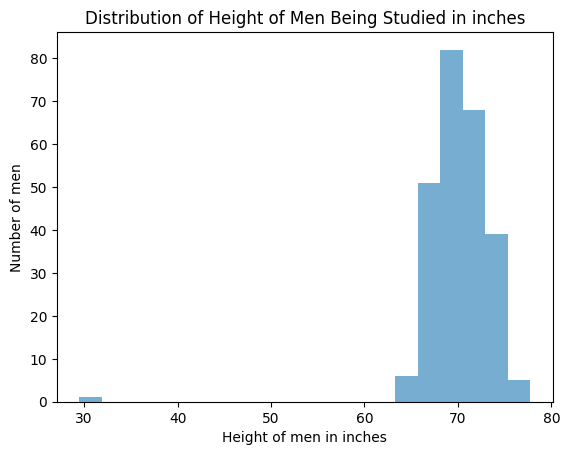

In [51]:
# Chart 3 - Histogram of the Height Column

plt.hist(body_fat['Height'], bins=20, alpha=0.6)
plt.xlabel("Height of men in inches")
plt.ylabel("Number of men")
plt.title("Distribution of Height of Men Being Studied in inches")
plt.show()

The last chart I found very interesting was the histogram of the height column. This chart stood out to me due to the high cencentration of the height values. Looking at the describe function, the height column has a very low standard deviation of 3.66, so this is to be expected. However, it can be seen that ther eis at least one outlier at around 30 inches of height. This chart stood out to me, due to the low standard deviation. The study may have benefitted from studying men of different heights as this may have affected the target variable. Therefore, the lack of variation in the height column can be a potential limitation of this dataset.

YOUR ANSWERS HERE

### Problem 4 (5 points)

Plot the correlation matrix of the numeric columns in the data set.
Which pair of different columns were highlighted as the most correlated?

In [52]:
# Plot the correlation matrix
corr = body_fat.corr(numeric_only=True)
corr

,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,target
Density,1.000000,-0.277637,-0.594062,0.097881,-0.472967,-0.682599,-0.798955,-0.609332,-0.553091,-0.987782
Age,-0.277637,1.000000,-0.012746,-0.171645,0.113505,0.176450,0.230409,-0.050332,-0.200096,0.291458
Weight,-0.594062,-0.012746,1.000000,0.308279,0.830716,0.894190,0.887995,0.940884,0.868694,0.612414
Height,0.097881,-0.171645,0.308279,1.000000,0.253710,0.134892,0.087813,0.170394,0.148436,-0.089495
Neck,-0.472967,0.113505,0.830716,0.253710,1.000000,0.784835,0.754077,0.734958,0.695697,0.490592
Chest,-0.682599,0.176450,0.894190,0.134892,0.784835,1.000000,0.915828,0.829420,0.729859,0.702620
Abdomen,-0.798955,0.230409,0.887995,0.087813,0.754077,0.915828,1.000000,0.874066,0.766624,0.813432
Hip,-0.609332,-0.050332,0.940884,0.170394,0.734958,0.829420,0.874066,1.000000,0.896410,0.625201
Thigh,-0.553091,-0.200096,0.868694,0.148436,0.695697,0.729859,0.766624,0.896410,1.000000,0.559608
target,-0.987782,0.291458,0.612414,-0.089495,0.490592,0.702620,0.813432,0.625201,0.559608,1.000000


In [53]:
# Look at just the highest correlated columns (top 10)
corr_pairs = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))  # remove diagonal
        .abs()
        .unstack()
        .sort_values(ascending=False)
)

corr_pairs.head(10)

Density  target     0.987782
target   Density    0.987782
Hip      Weight     0.940884
Weight   Hip        0.940884
Abdomen  Chest      0.915828
Chest    Abdomen    0.915828
Thigh    Hip        0.896410
Hip      Thigh      0.896410
Weight   Chest      0.894190
Chest    Weight     0.894190
dtype: float64

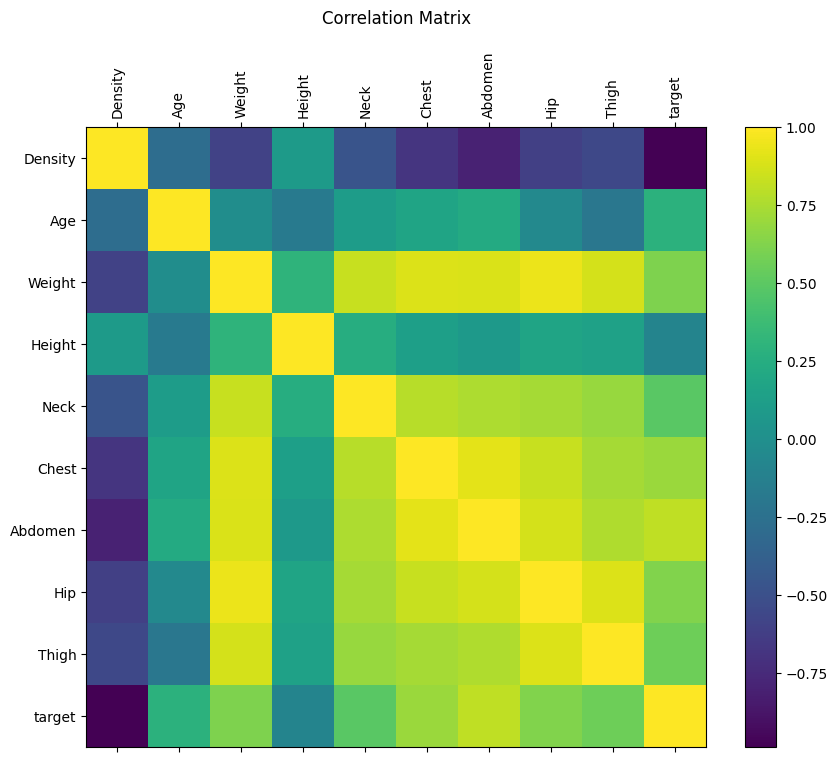

In [54]:
# Plot a heat map of column correlations

corr = body_fat.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.matshow(corr, fignum=1)
plt.title("Correlation Matrix", pad=20)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()
plt.show()


The pair of columns that have the highest correlation are density and the target column with 98.77% correlation

YOUR ANSWERS HERE

### Problem 5 (10 points)

Pick three different regression model classes to try in problem 6 from the scikit-learn documentation.
For each class, provide a link to the scikit-learn documentation, and a link to another web page describing how that kind of model works.
The second link should not be from scikit-learn, but Wikipedia is acceptable.
You do not need to understand the methods at this time, but it is good to be comfortable researching them.

In [ ]:
# YOUR CODE HERE

### Regression Model Class 1

**RandomForestRegressor**
* From sklearn.ensemble:  a tree based ensemble model that handles nonlinearities well.


Links:
* scikit-learn Documentation: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html
* How the Model Works: https://www.geeksforgeeks.org/machine-learning/random-forest-regression-in-python/

### Regression Model Class 2

**SVR (Support Vector Regressor)**
* From sklearn.svm: a kernel based method useful for complex relationships.


Links:
* scikit-learn Documentation: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html
* How the Modle works: https://howtolearnmachinelearning.com/articles/support-vector-regression/

### Regression Model Class 3

**KNeighborsRegressor**
* from sklearn.neighbors: Instance-based, non-parametric, good for local patterns.


Links:
* scikit-learn Documentation: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html
* How the model works: https://towardsdatascience.com/k-nearest-neighbor-regressor-explained-a-visual-guide-with-code-examples-df5052c8c889/

YOUR ANSWERS HERE

### Problem 6 (50 points)

Build three different regression models using the entire data set.
Plot the actual target vs the predicted values for each in one chart.
Compute the L2 and L1 losses for each of them.
You may use any regression class provided provided by scikit-learn, and you may reuse one class as long as you change its parameters enough to see different results.

In [26]:
# YOUR CODE HERE

In [57]:
input_cols = body_fat.drop(["target"], axis=1)
input_cols

,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh
0,1.0708,23.0,154.25,67.75,36.200001,93.099998,85.199997,94.500000,59.000000
1,1.0853,22.0,173.25,72.25,38.500000,93.599998,83.000000,98.699997,58.700001
2,1.0414,22.0,154.00,66.25,34.000000,95.800003,87.900002,99.199997,59.599998
3,1.0751,26.0,184.75,72.25,37.400002,101.800003,86.400002,101.199997,60.099998
4,1.0340,24.0,184.25,71.25,34.400002,97.300003,100.000000,101.900002,63.200001
...,...,...,...,...,...,...,...,...,...
247,1.0736,70.0,134.25,67.00,34.900002,89.199997,83.599998,88.800003,49.599998
248,1.0236,72.0,201.00,69.75,40.900002,108.500000,105.000000,104.500000,59.599998
249,1.0328,72.0,186.75,66.00,38.900002,111.099998,111.500000,101.699997,60.299999
250,1.0399,72.0,190.75,70.50,38.900002,108.300003,101.300003,97.800003,56.000000


In [58]:
target_col = body_fat["target"]
target_col

0      12.300000
1       6.100000
2      25.299999
3      10.400000
4      28.700001
         ...    
247    11.000000
248    33.599998
249    29.299999
250    26.000000
251    31.900000
Name: target, Length: 252, dtype: float64

### Regression Model 1 - RandomForestRegressor

In [69]:
from sklearn.ensemble import RandomForestRegressor

forest_regression_model= RandomForestRegressor(n_estimators=4, max_depth=4)

In [70]:
model_1_output = forest_regression_model.fit(input_cols, target_col)
model_1_output

,n_estimators,4
,criterion,'squared_error'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [71]:
# Predict the target from this model

model_1_predicitions = forest_regression_model.predict(input_cols)
model_1_predicitions

array([12.55625189,  5.13247492, 24.96924587,  9.95411993, 29.63383701,
       21.1541512 , 19.72475418, 12.55625189,  4.54715748, 11.12690737,
        8.54183385,  8.54183385, 20.64438929, 21.1541512 , 22.18404454,
       20.64438929, 29.63383701, 22.51289072, 15.77147729, 16.82051768,
       19.72475418, 14.61224482, 15.31182817, 17.52929287, 11.99567615,
        4.54715748,  8.28269919, 22.51289072,  4.54715748,  9.51081111,
       12.23048266,  6.61844777,  9.96051464, 21.1541512 , 32.79474127,
       37.83921445, 24.63442444, 28.94574182, 33.4343245 , 32.79474127,
       33.4343245 , 32.79474127, 31.79838287, 32.79474127,  8.28269919,
       14.00650952, 10.26475802, 10.22368419, 12.70336729,  4.54715748,
        9.95411993,  5.13247492,  8.28269919,  5.13247492,  4.54715748,
       22.51289072, 20.15352389, 27.78336049, 31.79838287, 24.96924587,
       25.86948409, 29.63383701, 29.63383701, 25.40281735, 32.79474127,
       29.63383701, 21.72307698, 14.00650952,  5.13247492, 12.55

In [72]:
# Check the score of the model

model_1_score = forest_regression_model.score(input_cols, target_col)
model_1_score

0.983622549064615

### Regression Model 2 - Support Vector Regressor

In [64]:
from sklearn.svm import SVR

svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)


In [65]:
model_2_output = svr_model.fit(input_cols, target_col)
model_2_output

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [66]:
# Predict the target from this model

model_2_predicitions = svr_model.predict(input_cols)
model_2_predicitions

array([14.66607676, 16.37141481, 15.09427903, 18.48410597, 19.38259601,
       22.01055893, 18.56905655, 17.47048688, 18.71453826, 19.96329755,
       18.26167029, 22.36010066, 19.00604184, 22.55313508, 20.32328615,
       17.15701609, 21.16837305, 22.82102051, 19.17385965, 23.28471597,
       19.12808987, 21.90755045, 12.85014383, 13.75337795, 13.82985601,
       14.65014399, 12.00080422, 14.86112235, 12.07925667, 15.67404184,
       18.52355277, 15.57032207, 15.58072201, 24.58201633, 27.74140049,
       23.94616748, 22.75497569, 22.58658722, 25.3728055 , 24.19451627,
       29.14316344, 24.14281841, 25.86638175, 24.01508796, 11.80902983,
       16.37966958, 12.37745695, 14.02222537, 13.57652858, 11.8859944 ,
       16.06277602, 13.12237968, 13.72295983, 14.97278676, 12.88762189,
       22.70025241, 21.08241637, 24.26633846, 23.88222834, 21.03957036,
       25.51995718, 20.26356943, 22.51298417, 20.98058221, 24.39431767,
       21.44604146, 15.47041805, 16.19318192, 15.48202078, 16.19

In [67]:
# Check the score of the model

model_2_score = svr_model.score(input_cols, target_col)
model_2_score

0.4677287389852194

YOUR ANSWERS HERE

### Problem 7 (30 points)

Use 5-fold cross-validation to repeat building the same three kinds of regression models. Compare the L2 losses predicted by cross-validation against the L2 losses training against the whole data set. (The difference is likely from overfitting in the latter.)

In [27]:
# YOUR CODE HERE

YOUR ANSWERS HERE

### Problem 8 (25 points)

Build three different regression models as in problem 6, but preprocess the data so that each column has mean zero and standard deviation one first.
For full credit, use a scikit-learn pipeline for each model.
For each model, compare the L2 losses -- which of them performed differently from your results in problem 6?

(This process will be covered in week 13.)

In [28]:
# YOUR CODE HERE

YOUR ANSWERS HERE

### Problem 9 (5 points)

A colleague suggests that you find better models by repeatedly building decision trees with random depth limits.
They say that trying 1000 such models will likely find an improvement as long as you use cross validation.
Give a one sentence response to this suggestion. 

In [29]:
# YOUR CODE HERE

YOUR ANSWERS HERE

### Problem 10 (10 points)

Pick a best model from all the models that you built and otherwise described in this project.
Explain how you picked it, including what criteria you chose, and how the other models compared by that criteria.
As much as possible, justify that problem in the context of the original data set. 

In [30]:
# YOUR CODE HERE

YOUR ANSWERS HERE